# Section 1: Data fundamentals 

Fetching data for: SAN from 2019-01-01 to 2024-12-31
Downloaded 1,509 trading days of data
Data inspection
Shape: 1509 rows and 6 columns
It goes from 2019-01-02 to 2024-12-30
The data types are
('Adj Close', 'SAN'): float64
('Close', 'SAN'): float64
('High', 'SAN'): float64
('Low', 'SAN'): float64
('Open', 'SAN'): float64
('Volume', 'SAN'): int64


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SAN,SAN,SAN,SAN,SAN,SAN
Date,,,,,,
2019-01-02,3.617105,4.51,4.53,4.40,4.40,8905500
2019-01-03,3.649187,4.55,4.58,4.52,4.55,6186700
2019-01-04,3.785529,4.72,4.75,4.68,4.70,6432200
2019-01-07,3.833651,4.78,4.82,4.73,4.75,6737000
2019-01-08,3.857712,4.81,4.84,4.78,4.83,4158600


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SAN,SAN,SAN,SAN,SAN,SAN
Date,,,,,,
2024-12-23,4.424594,4.50,4.51,4.46,4.48,3506000
2024-12-24,4.414762,4.49,4.52,4.48,4.51,1185600
2024-12-26,4.414762,4.49,4.53,4.48,4.48,1921900
2024-12-27,4.414762,4.49,4.56,4.48,4.51,4693200
2024-12-30,4.463924,4.54,4.56,4.50,4.52,3412000


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SAN,SAN,SAN,SAN,SAN,SAN
count,1509.000000,1509.000000,1509.000000,1509.000000,1509.000000,1.509000e+03
mean,3.243593,3.668290,3.701551,3.635222,3.668005,6.256441e+06
std,0.816103,0.841354,0.841159,0.842544,0.841786,4.837101e+06
min,1.517589,1.790000,1.840000,1.780000,1.800000,8.085000e+05
25%,2.674775,3.110000,3.150000,3.080000,3.100000,3.033300e+06
50%,3.274914,3.730000,3.770000,3.700000,3.730000,5.038800e+06
75%,3.734873,4.210000,4.240000,4.180000,4.200000,7.847800e+06
max,5.043554,5.250000,5.270000,5.210000,5.250000,5.023750e+07


No missing values
No columns with zero volume
No duplicated dates


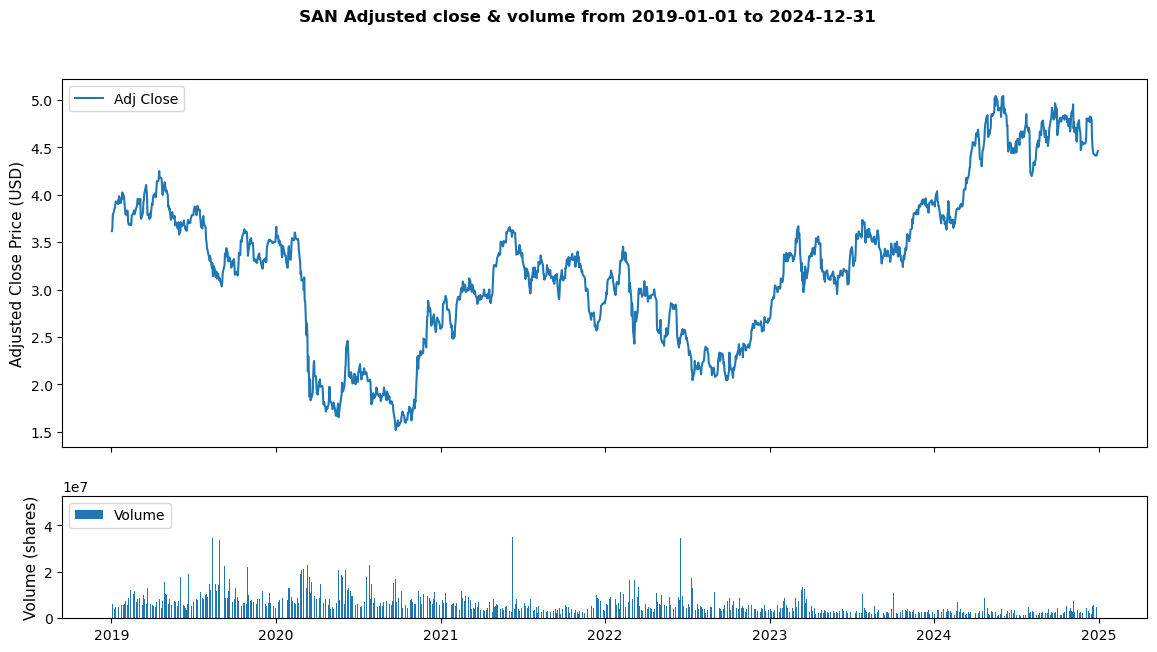

In [2]:
import sys
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates


%matplotlib inline

TICKER = "SAN"
START_DATE = "2019-01-01"
END_DATE = "2024-12-31"

def fetch_data(ticker, start, end):
    print(f"Fetching data for: {ticker} from {start} to {end}")

    raw = yf.download(
        tickers=ticker,
        start=start,
        end=end,
        auto_adjust=False,
        progress=False,
    )

    if raw.empty:
        print(f"[ERROR] there seems to be no data for {ticker} from {start} to {end}")
        sys.exit(1)

    print(f"Downloaded {len(raw):,} trading days of data")
    return raw

raw_df = fetch_data(TICKER, START_DATE, END_DATE)




def data_inspection(df):
    print("="*60)
    print("Data inspection")
    print("="*60)


    rows, col = df.shape
    print(f"Shape: {rows} rows and {col} columns")
    print(f"It goes from {df.index.min().date()} to {df.index.max().date()}")

    print("The data types are")
    for col, dtype in df.dtypes.items():
        print(f"{col}: {dtype}")

    display(df.head())
    display(df.tail())
    display(df.describe())

data_inspection(raw_df)




def data_quality(df, ticker):

    missing = df.isnull().sum()
    total_missing = missing.sum()

    if total_missing == 0:
        print("No missing values")
    else:
        print(f"there are a total of {total_missing} values")
        df = df.ffill()

    col_vol = [c for c in df.columns if "Volume" in str(c)][0]
    zero_volume = int((df[col_vol] == 0).sum())

    if zero_volume == 0:
        print("No columns with zero volume")
    else:
        print(f"There are a total of {zero_volume} rows with zero volume")
        df = df[df[col_vol] !=0]

    duplicate_dates = df.index.duplicated().sum()

    if duplicate_dates == 0:
        print("No duplicated dates")
    else: 
        print(f"There are a total of {duplicate_dates} duplicated dates")
        df = df[~df.index.duplicated(keep="first")]

    df=df.sort_index()

    return df 

def single_column_index(df):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]
    return df

quality_df = data_quality(raw_df, TICKER)
clean_df = single_column_index(quality_df)



def plot_price_volume(df, ticker):

    fig, (ax_price, ax_volume) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(14, 7),
        sharex=True,
        gridspec_kw={"height_ratios":[3,1]}
    )

    fig.suptitle(
        f"{ticker} Adjusted close & volume from {START_DATE} to {END_DATE}",
        fontweight="bold"
    )

    ax_price.plot(
        df.index,
        df["Adj Close"],
        label="Adj Close"
    )

    ax_price.set_ylabel("Adjusted Close Price (USD)", fontsize=11)
    ax_price.legend(loc="upper left", fontsize=10)

    ax_volume.bar(
        df.index,
        df["Volume"],
        label="Volume"
    )
    ax_volume.set_ylabel("Volume (shares)", fontsize=11)
    ax_volume.legend(loc="upper left", fontsize=10)
    
    ax_volume.xaxis.set_major_locator(mdates.YearLocator())
    ax_volume.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    
    plt.show()


plot_price_volume(clean_df, TICKER)


# Section 2: Returns & Statistics

,simple_return,log_return
Date,,
2019-01-03,0.008869,0.008830
2019-01-04,0.037362,0.036681
2019-01-07,0.012712,0.012632
2019-01-08,0.006276,0.006257
2019-01-09,0.002079,0.002077


  RETURN STATISTICS — SAN

  Metric                                   Daily     Annual
  -------------------------------------------------------
  Mean Log Return                        0.0139%    3.5152%
  Mean Simple Return                     0.0431%   10.8552%
  Volatility (Log Returns)               2.4200%   38.4159%

  Skewness                               -0.6573
  Excess Kurtosis                         7.7792

  Notes:
  - Skewness < 0 means the distribution has a longer left tail
    (more frequent small gains, rarer but larger losses)
  - Excess kurtosis > 0 means fatter tails than a normal distribution
    (extreme moves happen more often than standard models assume)
[INFO] Chart saved to 'section2_return_distribution.png'


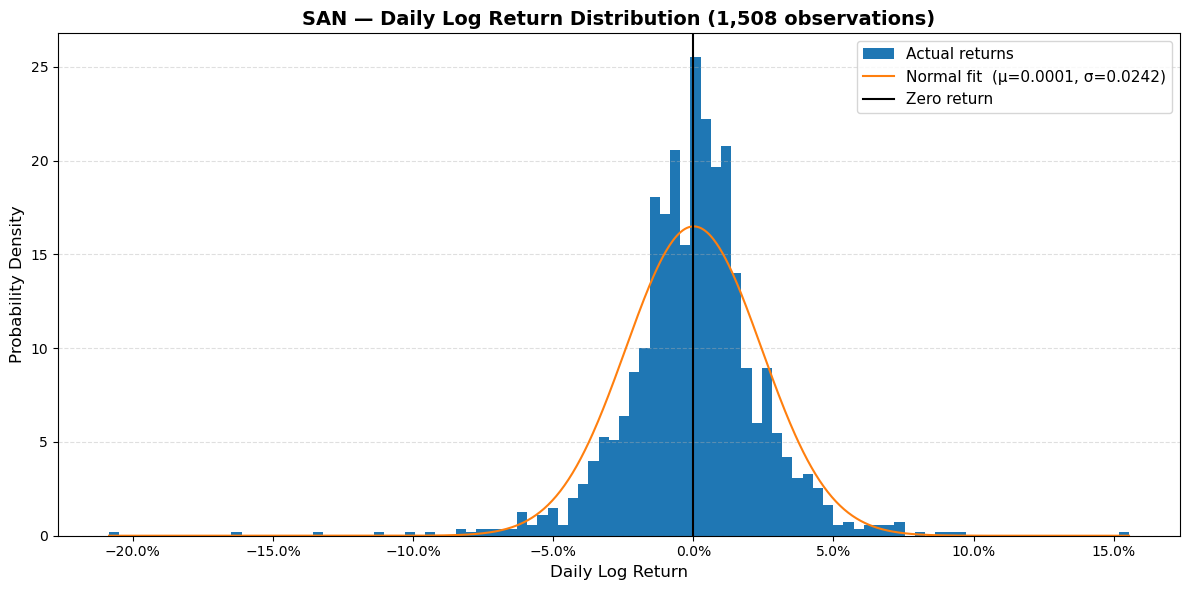

[INFO] Chart saved to 'section2_cumulative_return.png'


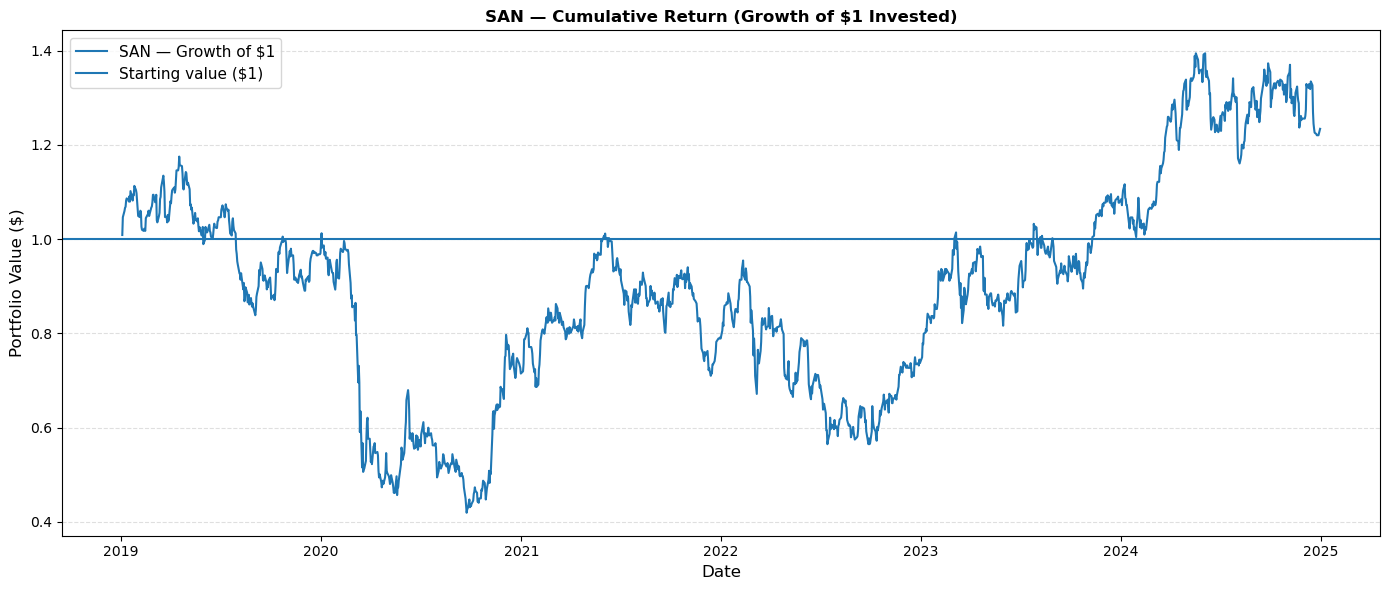

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats


TRADING_DAYS_PER_YEAR=252


def compute_returns(df):
    df["simple_return"] = df["Adj Close"].pct_change()
    
    df["log_return"] = np.log(df["Adj Close"]/df["Adj Close"].shift(1))
    df = df.dropna(subset=["simple_return","log_return"])

    display(df[["simple_return", "log_return"]].head())

    return df 

returns_df = compute_returns(clean_df)




def compute_statistics(df, ticker):
    log_ret = df["log_return"]
    simple_ret = df["simple_return"]
    
    
    daily_mean_log    = log_ret.mean()
    daily_mean_simple = simple_ret.mean()
    daily_vol         = log_ret.std()    
    daily_skew        = log_ret.skew()
    daily_kurt        = log_ret.kurt()  
    

    annual_mean_log    = daily_mean_log  * TRADING_DAYS_PER_YEAR
    annual_mean_simple = daily_mean_simple * TRADING_DAYS_PER_YEAR
    annual_vol         = daily_vol       * np.sqrt(TRADING_DAYS_PER_YEAR)
    
 
    print("=" * 60)
    print(f"  RETURN STATISTICS — {ticker}")
    print("=" * 60)
    
    print(f"\n  {'Metric':<35} {'Daily':>10} {'Annual':>10}")
    print(f"  {'-'*55}")
    print(f"  {'Mean Log Return':<35} {daily_mean_log:>10.4%} {annual_mean_log:>10.4%}")      
    print(f"  {'Mean Simple Return':<35} {daily_mean_simple:>10.4%} {annual_mean_simple:>10.4%}")
    print(f"  {'Volatility (Log Returns)':<35} {daily_vol:>10.4%} {annual_vol:>10.4%}")       
    print(f"\n  {'Skewness':<35} {daily_skew:>10.4f}")
    print(f"  {'Excess Kurtosis':<35} {daily_kurt:>10.4f}")
    
    print(f"\n  Notes:")
    print(f"  - Skewness < 0 means the distribution has a longer left tail")
    print(f"    (more frequent small gains, rarer but larger losses)")
    print(f"  - Excess kurtosis > 0 means fatter tails than a normal distribution")
    print(f"    (extreme moves happen more often than standard models assume)")
    
  
    return {
      "daily_mean_log"    : daily_mean_log,
      "daily_mean_simple" : daily_mean_simple,
      "daily_vol"         : daily_vol,
      "annual_mean_log"   : annual_mean_log,
      "annual_mean_simple": annual_mean_simple,
      "annual_vol"        : annual_vol,
      "skewness"          : daily_skew,
      "excess_kurtosis"   : daily_kurt,
    }
    
   
stats_dict: dict = compute_statistics(returns_df, TICKER)





def plot_return_distribution(df, ticker):        

  log_ret = df["log_return"].dropna()
  mu, sigma = stats.norm.fit(log_ret)
  fig, ax = plt.subplots(figsize=(12, 6))

  
  ax.hist(
      log_ret,
      bins=100,           
      density=True,          
      label="Actual returns",
  )

  x = np.linspace(log_ret.min(), log_ret.max(), 1000)
  
  ax.plot(
      x,
      stats.norm.pdf(x, mu, sigma),  
      label=f"Normal fit  (μ={mu:.4f}, σ={sigma:.4f})",
  )

  ax.axvline(
      x=0,
      color="black",
      label="Zero return",
  )

  ax.set_title(
      f"{ticker} — Daily Log Return Distribution ({len(log_ret):,} observations)",
      fontsize=14,
      fontweight="bold",
  )
  ax.set_xlabel("Daily Log Return", fontsize=12)
  ax.set_ylabel("Probability Density", fontsize=12)
  ax.legend(fontsize=11)
  ax.grid(axis="y", linestyle="--", alpha=0.4)

  ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1,decimals=1))

  plt.tight_layout()
  plt.savefig("section2_return_distribution.png", dpi=150,bbox_inches="tight")
  print("[INFO] Chart saved to 'section2_return_distribution.png'")       
  plt.show()

plot_return_distribution(returns_df, TICKER)




def plot_cumulative_returns(df, ticker):
 
  cumulative_log_return = df["log_return"].cumsum()


  growth_of_one_dollar = np.exp(cumulative_log_return)

  fig, ax = plt.subplots(figsize=(14, 6))

  ax.plot(
      df.index,
      growth_of_one_dollar,
      label=f"{ticker} — Growth of $1",
  )

  ax.axhline(
      y=1.0,
      label="Starting value ($1)",
  )

  ax.set_title(
      f"{ticker} — Cumulative Return (Growth of $1 Invested)",
      fontweight="bold",
  )
  ax.set_xlabel("Date", fontsize=12)
  ax.set_ylabel("Portfolio Value ($)", fontsize=12)
  ax.legend(fontsize=11)
  ax.grid(axis="y", linestyle="--", alpha=0.4)

  plt.tight_layout()
  plt.savefig("section2_cumulative_return.png", dpi=150, bbox_inches="tight")
  print("[INFO] Chart saved to 'section2_cumulative_return.png'")
  plt.show()


plot_cumulative_returns(returns_df, TICKER)

# Section 3: Technical indicators

[INFO] SMA_50 and SMA_200 computed.
       First valid SMA_50 date : 2019-03-15
       First valid SMA_200 date  : 2019-10-17
[INFO] RSI(14) computed.
       First valid RSI date: 2019-01-24


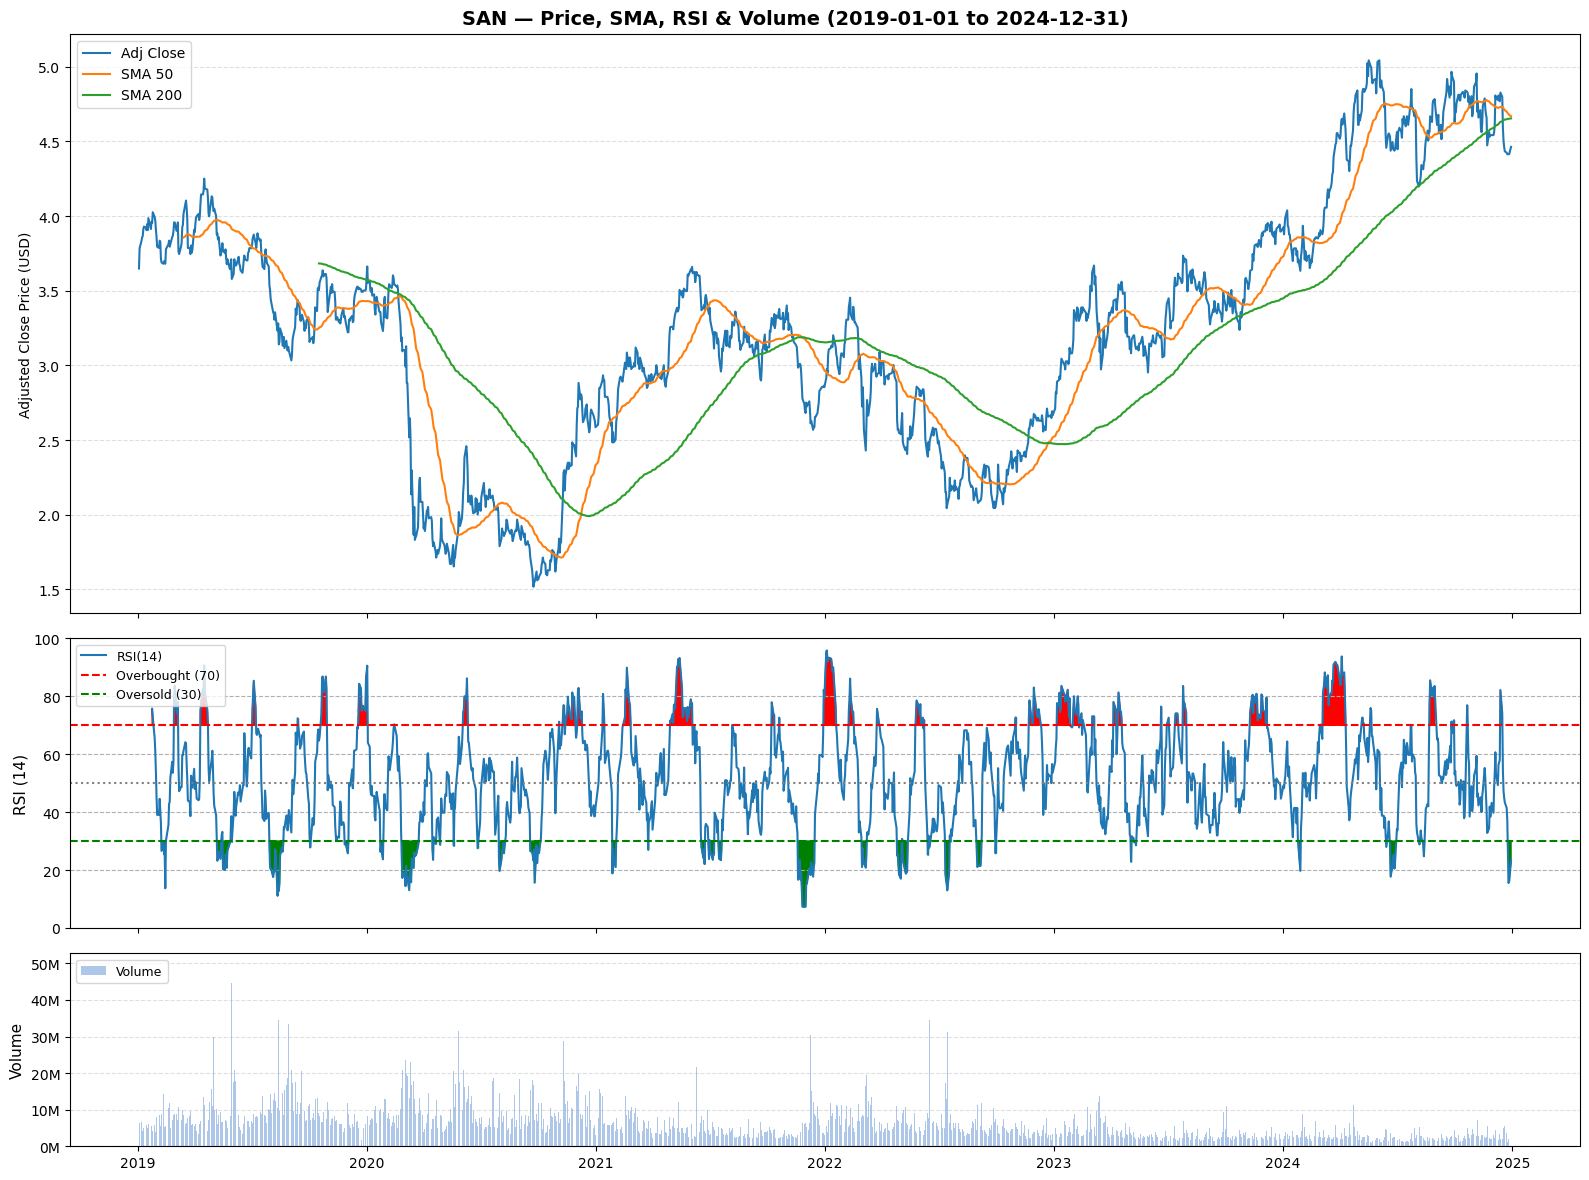

In [23]:
import numpy as np                                                                               
import pandas as pd                                                                            
import matplotlib.pyplot as plt                                                                
import matplotlib.dates as mdates                                                                 
%matplotlib inline                                                                                
              
SMA_SHORT:  int = 50    
SMA_LONG:   int = 200                                
RSI_PERIOD: int = 14   

def compute_sma(df):                                                                                         
    df[f"SMA_{SMA_SHORT}"] = df["Adj Close"].rolling(window=SMA_SHORT).mean()
    df[f"SMA_{SMA_LONG}"]  = df["Adj Close"].rolling(window=SMA_LONG).mean()                   
    print(f"[INFO] SMA_{SMA_SHORT} and SMA_{SMA_LONG} computed.")                                    
    print(f"       First valid SMA_{SMA_SHORT} date : {df[f'SMA_{SMA_SHORT}'].first_valid_index().date()}")                                                
    print(f"       First valid SMA_{SMA_LONG} date  : {df[f'SMA_{SMA_LONG}'].first_valid_index().date()}")                                              
    return df                                                                                  

               
indicators_df = compute_sma(returns_df.copy())                                   
                                                                

def compute_rsi(df, period: int = RSI_PERIOD):
   
    delta = df["Adj Close"].diff()


    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)


    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss

    df["RSI"] = 100 - (100 / (1 + rs))

    print(f"[INFO] RSI({period}) computed.")
    print(f"       First valid RSI date: {df['RSI'].first_valid_index().date()}")

    return df
indicators_df = compute_rsi(indicators_df) 



def plot_indicators(df, ticker):
    fig, (ax_price, ax_rsi, ax_vol) = plt.subplots(
        nrows=3, ncols=1, figsize=(16, 12),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1.5, 1]},
    )

    fig.suptitle(
        f"{ticker} — Price, SMA, RSI & Volume ({START_DATE} to {END_DATE})",
        fontsize=14, fontweight="bold",
    )

   
    ax_price.plot(df.index, df["Adj Close"], label="Adj Close")
    ax_price.plot(df.index, df[f"SMA_{SMA_SHORT}"], label=f"SMA {SMA_SHORT}")
    ax_price.plot(df.index, df[f"SMA_{SMA_LONG}"],  label=f"SMA {SMA_LONG}")
    ax_price.set_ylabel("Adjusted Close Price (USD)")
    ax_price.legend(loc="upper left")
    ax_price.grid(axis="y", linestyle="--", alpha=0.4)

    
    ax_rsi.plot(df.index, df["RSI"], label=f"RSI({RSI_PERIOD})")
    ax_rsi.axhline(y=70, color="red",   linestyle="--", label="Overbought (70)")
    ax_rsi.axhline(y=30, color="green", linestyle="--", label="Oversold (30)")
    ax_rsi.axhline(y=50, color="gray",  linestyle=":")
    ax_rsi.fill_between(df.index, 70, df["RSI"], where=(df["RSI"] >= 70), color="red")
    ax_rsi.fill_between(df.index, 30, df["RSI"], where=(df["RSI"] <= 30), color="green")
    ax_rsi.set_ylabel(f"RSI ({RSI_PERIOD})", fontsize=11)
    ax_rsi.set_ylim(0, 100)
    ax_rsi.legend(loc="upper left", fontsize=9)
    ax_rsi.grid(axis="y", linestyle="--")

    
    ax_vol.bar(df.index, df["Volume"], color="#aec7e8", width=1, label="Volume")
    ax_vol.set_ylabel("Volume", fontsize=11)
    ax_vol.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x / 1e6:.0f}M"))
    ax_vol.legend(loc="upper left", fontsize=9)
    ax_vol.grid(axis="y", linestyle="--", alpha=0.4)

    ax_vol.xaxis.set_major_locator(mdates.YearLocator())
    ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig("section3_indicators.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_indicators(indicators_df, TICKER)




# Section 4: Signal 

  TRADE SUMMARY — SAN

  Total buy  signals : 2
  Total sell signals : 1

  #     Entry Date      Exit Date      
  -----------------------------------
  1     2020-12-10      2021-11-29     


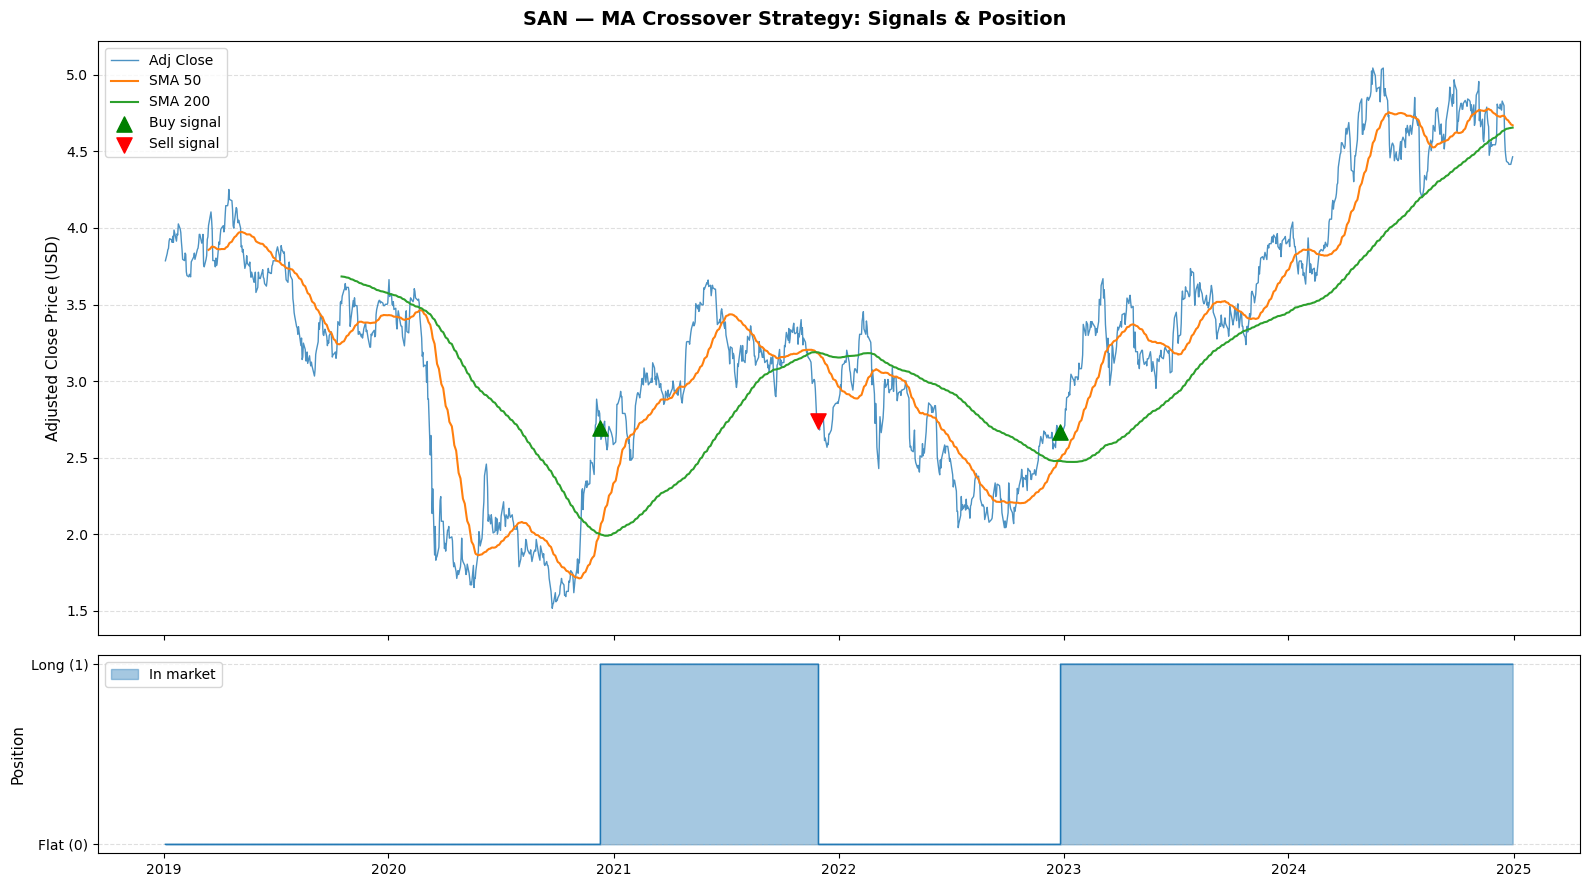

In [15]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline


SMA_SHORT: int = 50
SMA_LONG:  int = 200

def generate_signals(df):
    df["signal"] = np.where(
        df[f"SMA_{SMA_SHORT}"] > df[f"SMA_{SMA_LONG}"], 1, 0
    )


    df["position"] = df["signal"].shift(1)


    df = df.dropna(subset=["position"])
    return df

signals_df = generate_signals(indicators_df.copy())

def summarise_trades(df, ticker):
  
    position_change = df["position"].diff()

    entries = df.index[position_change ==  1]  
    exits   = df.index[position_change == -1]  

    print("=" * 60)
    print(f"  TRADE SUMMARY — {ticker}")
    print("=" * 60)
    print(f"\n  Total buy  signals : {len(entries)}")
    print(f"  Total sell signals : {len(exits)}")
    print(f"\n  {'#':<5} {'Entry Date':<15} {'Exit Date':<15}")
    print(f"  {'-' * 35}")

    for i, (entry, exit_) in enumerate(zip(entries, exits), start=1):
        print(f"  {i:<5} {str(entry.date()):<15} {str(exit_.date()):<15}")

summarise_trades(signals_df, TICKER)

def plot_signals(df, ticker):
    
    position_change = df["position"].diff()
    entries = df[position_change ==  1]
    exits   = df[position_change == -1]

    fig, (ax_price, ax_pos) = plt.subplots(
        nrows=2, ncols=1,
        figsize=(16, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    fig.suptitle(
        f"{ticker} — MA Crossover Strategy: Signals & Position",
        fontsize=14, fontweight="bold",
    )

 
    ax_price.plot(df.index, df["Adj Close"],
                  color="#1f77b4", linewidth=1.0, label="Adj Close", alpha=0.8)
    ax_price.plot(df.index, df[f"SMA_{SMA_SHORT}"],
                  color="#ff7f0e", linewidth=1.5, label=f"SMA {SMA_SHORT}")
    ax_price.plot(df.index, df[f"SMA_{SMA_LONG}"],
                  color="#2ca02c", linewidth=1.5, label=f"SMA {SMA_LONG}")

    ax_price.scatter(entries.index, entries["Adj Close"],
                     marker="^", color="green", s=120, zorder=5, label="Buy signal")
    ax_price.scatter(exits.index, exits["Adj Close"],
                     marker="v", color="red",   s=120, zorder=5, label="Sell signal")

    ax_price.set_ylabel("Adjusted Close Price (USD)", fontsize=11)
    ax_price.legend(loc="upper left", fontsize=10)
    ax_price.grid(axis="y", linestyle="--", alpha=0.4)


    ax_pos.fill_between(df.index, df["position"],
                        step="post", alpha=0.4, color="#1f77b4", label="In market")
    ax_pos.plot(df.index, df["position"],
                drawstyle="steps-post", color="#1f77b4", linewidth=1.0)

    ax_pos.set_ylabel("Position", fontsize=11)
    ax_pos.set_yticks([0, 1])
    ax_pos.set_yticklabels(["Flat (0)", "Long (1)"])
    ax_pos.legend(loc="upper left", fontsize=10)
    ax_pos.grid(axis="y", linestyle="--", alpha=0.4)

    ax_pos.xaxis.set_major_locator(mdates.YearLocator())
    ax_pos.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig("section4_signals.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_signals(signals_df, TICKER)

[INFO] Backtest complete.
  Transaction cost applied : 0.1% per trade
  Strategy final value     : $1.67
  Benchmark final value    : $1.22


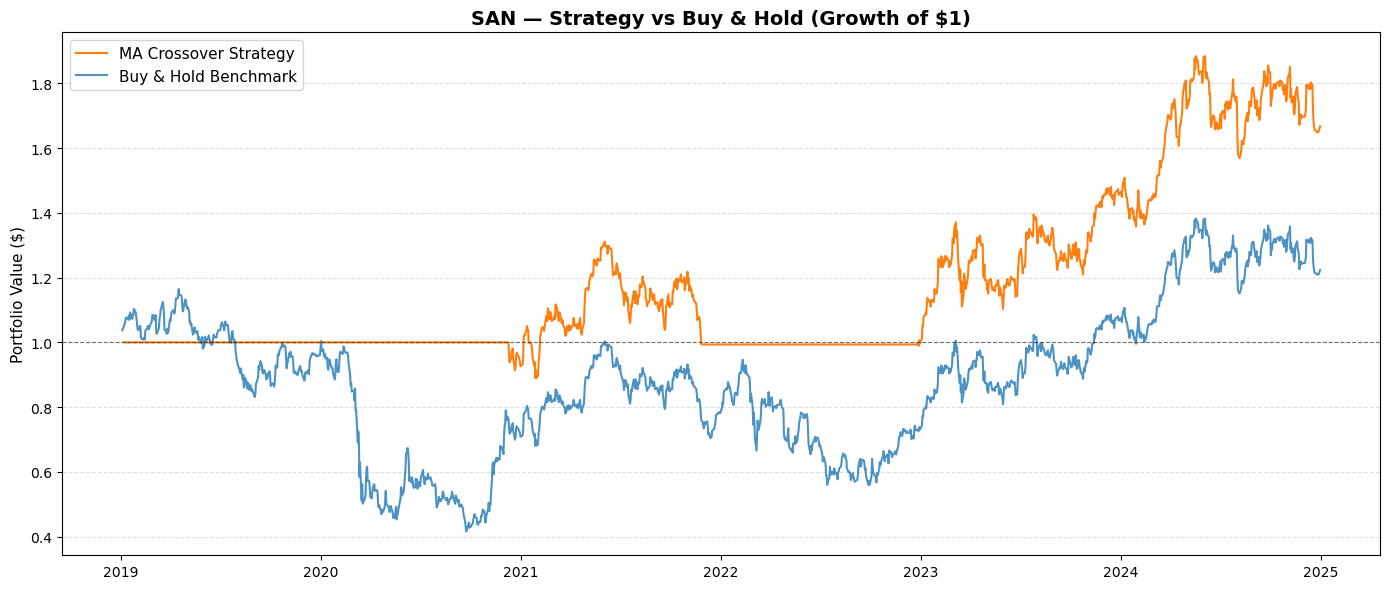

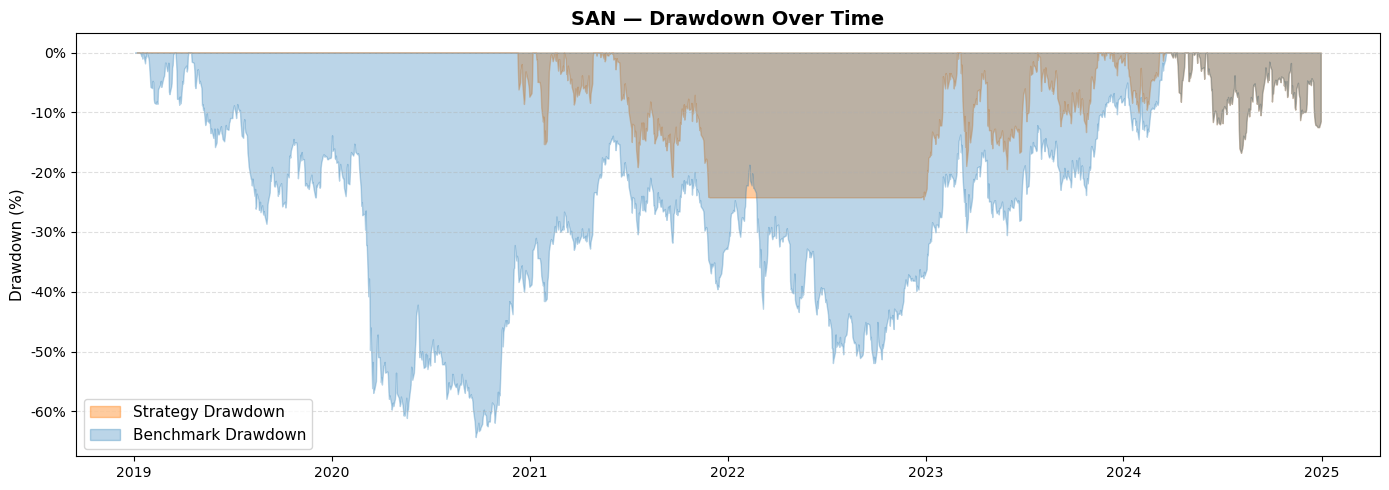

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline


TRANSACTION_COST: float = 0.001  

def run_backtest(df):
  
    df["strategy_return"] = df["position"] * df["log_return"]

    position_change = df["position"].diff().abs()
    df["strategy_return"] -= position_change * TRANSACTION_COST

    df["benchmark_return"] = df["log_return"]

    
    df["strategy_equity"]  = np.exp(df["strategy_return"].cumsum())
    df["benchmark_equity"] = np.exp(df["benchmark_return"].cumsum())

    print(f"[INFO] Backtest complete.")
    print(f"  Transaction cost applied : {TRANSACTION_COST:.1%} per trade")
    print(f"  Strategy final value     : ${df['strategy_equity'].iloc[-1]:.2f}")
    print(f"  Benchmark final value    : ${df['benchmark_equity'].iloc[-1]:.2f}")

    return df

def plot_equity_curves(df, ticker):

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(df.index, df["strategy_equity"],
            color="#ff7f0e", linewidth=1.5, label="MA Crossover Strategy")
    ax.plot(df.index, df["benchmark_equity"],
            color="#1f77b4", linewidth=1.5, label="Buy & Hold Benchmark", alpha=0.8)

    ax.axhline(y=1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

    ax.set_title(
        f"{ticker} — Strategy vs Buy & Hold (Growth of $1)",
        fontsize=14, fontweight="bold",
    )
    ax.set_ylabel("Portfolio Value ($)", fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig("section5_equity_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

def plot_drawdowns(df, ticker):
  
    strategy_peak  = df["strategy_equity"].cummax()
    benchmark_peak = df["benchmark_equity"].cummax()

    strategy_dd  = (df["strategy_equity"]  - strategy_peak)  / strategy_peak
    benchmark_dd = (df["benchmark_equity"] - benchmark_peak) / benchmark_peak

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.fill_between(df.index, strategy_dd,
                    alpha=0.4, color="#ff7f0e", label="Strategy Drawdown")
    ax.fill_between(df.index, benchmark_dd,
                    alpha=0.3, color="#1f77b4", label="Benchmark Drawdown")

    ax.set_title(
        f"{ticker} — Drawdown Over Time",
        fontsize=14, fontweight="bold",
    )
    ax.set_ylabel("Drawdown (%)", fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.legend(fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.savefig("section5_drawdowns.png", dpi=150, bbox_inches="tight")
    plt.show()


backtest_df = run_backtest(signals_df.copy())
plot_equity_curves(backtest_df, TICKER)
plot_drawdowns(backtest_df, TICKER)

In [17]:

import numpy as np
import pandas as pd


TRADING_DAYS_PER_YEAR: int   = 252
RISK_FREE_RATE:        float = 0.05  

def compute_sharpe_ratio(returns, risk_free_rate: float = RISK_FREE_RATE):

    daily_rf      = risk_free_rate / TRADING_DAYS_PER_YEAR
    excess_return = returns - daily_rf
    mean          = excess_return.mean() * TRADING_DAYS_PER_YEAR
    vol           = excess_return.std()  * np.sqrt(TRADING_DAYS_PER_YEAR)
    return mean / vol

def compute_max_drawdown(equity_curve):
    
    peak     = equity_curve.cummax()
    drawdown = (equity_curve - peak) / peak
    return drawdown.min()

def compute_win_rate(strategy_returns, position):
    
    active_returns = strategy_returns[position == 1]
    return (active_returns > 0).sum() / len(active_returns)

def compute_calmar_ratio(equity_curve):
   
    total_return   = np.log(equity_curve.iloc[-1] / equity_curve.iloc[0])
    n_years        = len(equity_curve) / TRADING_DAYS_PER_YEAR
    annualised_ret = total_return / n_years
    max_dd         = abs(compute_max_drawdown(equity_curve))
    return annualised_ret / max_dd if max_dd != 0 else np.nan

def print_performance_report(df, ticker):
    
    strat_sharpe  = compute_sharpe_ratio(df["strategy_return"])
    strat_mdd     = compute_max_drawdown(df["strategy_equity"])
    strat_calmar  = compute_calmar_ratio(df["strategy_equity"])
    strat_winrate = compute_win_rate(df["strategy_return"], df["position"])
    strat_ann_ret = df["strategy_return"].mean() * TRADING_DAYS_PER_YEAR
    strat_ann_vol = df["strategy_return"].std()  * np.sqrt(TRADING_DAYS_PER_YEAR)
    time_in_mkt   = df["position"].mean()

    
    bench_sharpe  = compute_sharpe_ratio(df["benchmark_return"])
    bench_mdd     = compute_max_drawdown(df["benchmark_equity"])
    bench_calmar  = compute_calmar_ratio(df["benchmark_equity"])
    bench_ann_ret = df["benchmark_return"].mean() * TRADING_DAYS_PER_YEAR
    bench_ann_vol = df["benchmark_return"].std()  * np.sqrt(TRADING_DAYS_PER_YEAR)

    
    print("=" * 65)
    print(f"  PERFORMANCE REPORT — {ticker}")
    print("=" * 65)
    print(f"\n  {'Metric':<30} {'Strategy':>15} {'Benchmark':>15}")
    print(f"  {'-' * 60}")
    print(f"  {'Annualised Return':<30} {strat_ann_ret:>15.2%} {bench_ann_ret:>15.2%}")
    print(f"  {'Annualised Volatility':<30} {strat_ann_vol:>15.2%} {bench_ann_vol:>15.2%}")
    print(f"  {'Sharpe Ratio':<30} {strat_sharpe:>15.2f} {bench_sharpe:>15.2f}")
    print(f"  {'Maximum Drawdown':<30} {strat_mdd:>15.2%} {bench_mdd:>15.2%}")
    print(f"  {'Calmar Ratio':<30} {strat_calmar:>15.2f} {bench_calmar:>15.2f}")
    print(f"  {'Win Rate (active days)':<30} {strat_winrate:>15.2%} {'N/A':>15}")
    print(f"  {'Time in Market':<30} {time_in_mkt:>15.2%} {'100.00%':>15}")

    print(f"\n  INTERPRETATION")
    print(f"  {'-' * 60}")

    if strat_sharpe > bench_sharpe:
        print(f"  [+] Strategy has a higher Sharpe — better risk-adjusted return")
    else:
        print(f"  [-] Strategy has a lower Sharpe — worse risk-adjusted return than buy & hold")

    if abs(strat_mdd) < abs(bench_mdd):
        print(f"  [+] Strategy has a smaller max drawdown — less downside pain")
    else:
        print(f"  [-] Strategy has a larger max drawdown — more downside pain")

    if strat_ann_ret > bench_ann_ret:
        print(f"  [+] Strategy outperformed buy & hold in raw annual return")
    else:
        print(f"  [-] Strategy underperformed buy & hold in raw annual return")

    print(f"\n  HONEST LIMITATIONS")
    print(f"  {'-' * 60}")
    print(f"  - Results are in-sample: strategy was built on the same data it was tested on")
    print(f"  - No walk-forward or out-of-sample validation was performed")
    print(f"  - SMA windows (50/200) were chosen by convention, not optimised statistically")
    print(f"  - A single 6-year period may not represent all market regimes")


print_performance_report(backtest_df, TICKER)


  PERFORMANCE REPORT — SAN

  Metric                                Strategy       Benchmark
  ------------------------------------------------------------
  Annualised Return                        8.56%           3.37%
  Annualised Volatility                   21.00%          38.43%
  Sharpe Ratio                              0.17           -0.04
  Maximum Drawdown                       -24.54%         -64.30%
  Calmar Ratio                               nan            0.04
  Win Rate (active days)                  50.27%             N/A
  Time in Market                          49.64%         100.00%

  INTERPRETATION
  ------------------------------------------------------------
  [+] Strategy has a higher Sharpe — better risk-adjusted return
  [+] Strategy has a smaller max drawdown — less downside pain
  [+] Strategy outperformed buy & hold in raw annual return

  HONEST LIMITATIONS
  ------------------------------------------------------------
  - Results are in-sample: strategy